<a href="https://colab.research.google.com/github/LamisAbdallah/Space-Caption-Generator/blob/main/ViT_GPT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup the environment**


In [1]:
!pip install -q transformers datasets evaluate rouge-score gradio

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00


# **Space Image Captioning with ViT-GPT2**

## Problem Statement
Given an image of a space object (galaxy, nebula, planet, star cluster),
automatically generate a short descriptive caption.

## Model Choice: ViT-GPT2
We use `nlpconnect/vit-gpt2-image-captioning`, a Vision Encoder-Decoder model:
- **ViT (encoder)**: splits the image into 16×16 patches, processes them
  as a sequence using self-attention across 12 transformer layers
- **GPT-2 (decoder)**: generates captions word-by-word using cross-attention
  to "look at" the image while writing

## Why this model?
- Directly covers Transformers, ViTs, and pretrained models (rubric focus)
- End-to-end: takes image → outputs text with no intermediate steps
- Strong pretrained base (COCO dataset, 330k images) to fine-tune from

# **Dataset Loading & Exploration**



We use our own NASA space image dataset stored locally.

In [4]:
from google.colab import files
import zipfile
import os

# Step 1: upload CSV
print("Upload vlm_captions_dataset.csv")
uploaded = files.upload()

# Step 2: upload images zip
print("\nUpload vlm_images.zip")
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print(f"Extracting {zip_name}...")
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(".")

print(f"\nCSV exists: {os.path.exists('vlm_captions_dataset.csv')}")
print(f"Images exist: {os.path.exists('vlm_images')}")

Upload vlm_captions_dataset.csv


Saving vlm_captions_dataset.csv to vlm_captions_dataset.csv

Upload vlm_images.zip


Saving vlm_images.zip to vlm_images.zip
Extracting vlm_images.zip...

CSV exists: True
Images exist: True


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

CSV_PATH   = "vlm_captions_dataset.csv"
IMAGES_DIR = "vlm_images"

df = pd.read_csv(CSV_PATH)
print(f"Total rows: {len(df)}")
print(df.head())
print(f"\nCategories:\n{df['category'].value_counts()}")


Total rows: 210
  object_id category                                          title  \
0  PIA04499   planet  Proposed Missions - Terrestrial Planet Finder   
1  PIA09259   planet             Simulating Planet-Hunting in a Lab   
2  PIA16823   planet                   Another Girl, Another Planet   
3  PIA11247   planet      MESSENGER Encounters the Innermost Planet   
4  PIA14354   planet                   A Swiftly Non-Tilting Planet   

                                             caption          image_file_path  
0  NASA Terrestrial Planet Finder will use multip...  vlm_images/PIA04499.jpg  
1  Three simulated planets -- one as bright as Ju...  vlm_images/PIA09259.jpg  
2                       Another Girl, Another Planet  vlm_images/PIA16823.jpg  
3          MESSENGER Encounters the Innermost Planet  vlm_images/PIA11247.jpg  
4                       A Swiftly Non-Tilting Planet  vlm_images/PIA14354.jpg  

Categories:
category
planet          32
galaxy          32
nebula          3

 **Clean captions:**
 * Some rows have caption = title (short, useless for training).
*  We use the caption only if it's meaningfully longer than the title,
 * otherwise we fall back to the title itself.





**Drop rows where the image file doesn't exist on disk**

In [6]:
df = pd.read_csv(CSV_PATH)

df['text'] = df.apply(
    lambda row: row['caption']
    if isinstance(row['caption'], str)
    and len(row['caption']) > len(str(row['title'])) + 20
    else row['title'],
    axis=1
)

# Drop rows where image doesn't exist on disk

df = df[df['image_file_path'].apply(
    lambda p: os.path.exists(os.path.join(IMAGES_DIR, os.path.basename(p)))
)].reset_index(drop=True)

print(f"Rows after cleaning: {len(df)}")
print(f"Sample path check: {df['image_file_path'].iloc[0]}")

Rows after cleaning: 210
Sample path check: vlm_images/PIA04499.jpg


**Visualize 8 sample images with their captions**

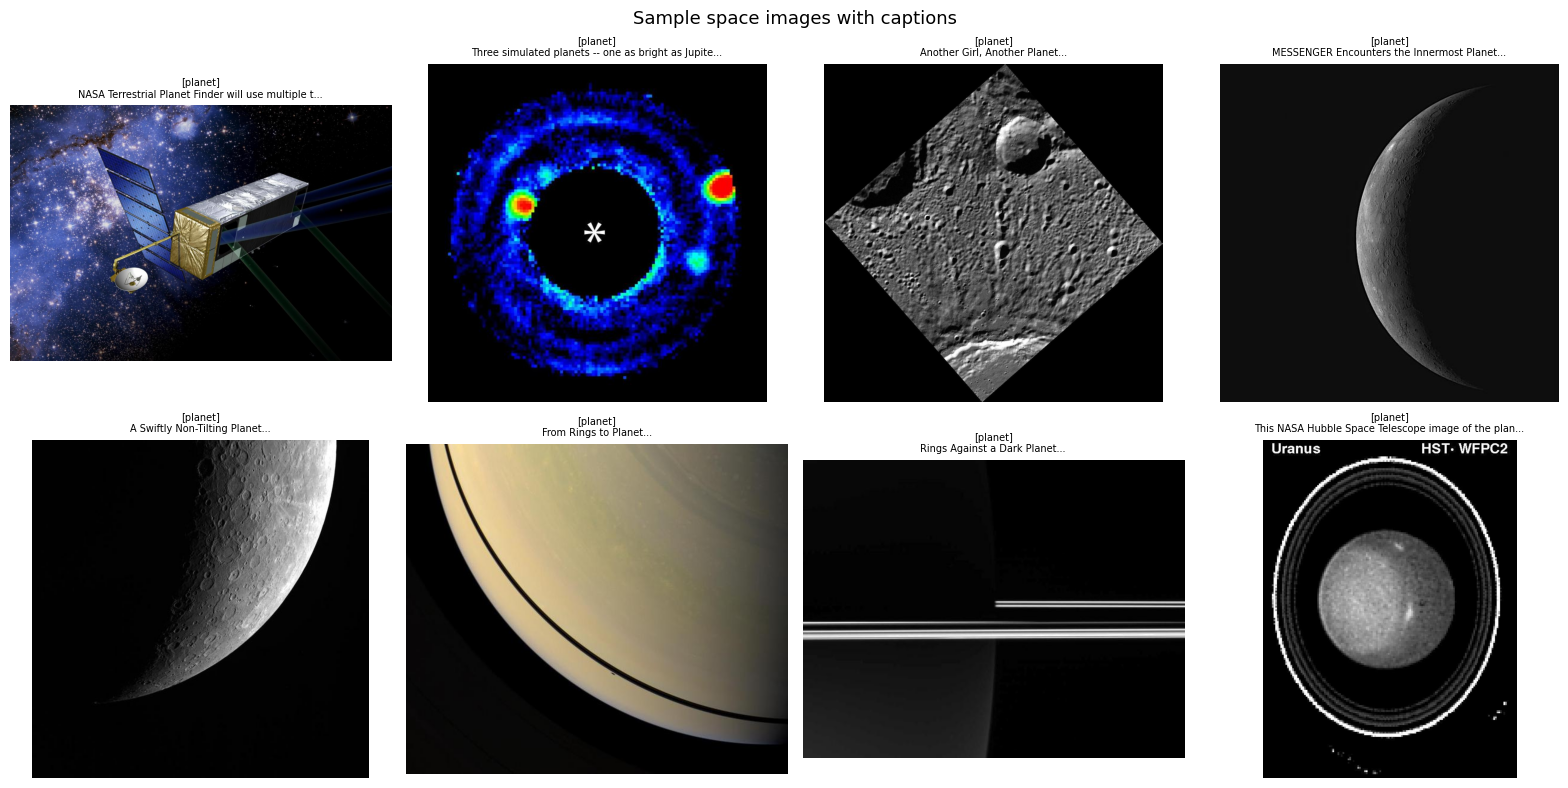

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    row = df.iloc[i]
    img_path = os.path.join(IMAGES_DIR, os.path.basename(row['image_file_path']))
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"[{row['category']}]\n{row['text'][:50]}...", fontsize=7)
    ax.axis('off')
plt.suptitle("Sample space images with captions", fontsize=13)
plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

# **Load Pretrained Model**

 * We load **ViT-GPT2** from HuggingFace.
At this stage the model has no knowledge
of space images — it was trained on COCO (everyday objects like dogs, cars, people).
We will test it as-is first to establish a baseline, then fine-tune it.



In [8]:
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

MODEL_NAME = "nlpconnect/vit-gpt2-image-captioning"

model             = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
feature_extractor = ViTImageProcessor.from_pretrained(MODEL_NAME)
tokenizer         = AutoTokenizer.from_pretrained(MODEL_NAME)

# Required: set special tokens for the decoder
tokenizer.pad_token                          = tokenizer.eos_token
model.config.pad_token_id                    = tokenizer.pad_token_id
model.config.decoder_start_token_id          = tokenizer.bos_token_id

model.to(device)
print("Model loaded ✓")

# Generation parameters
gen_kwargs = {
    "max_length": 50,           # max caption length
    "num_beams": 4,             # beam search: explore 4 paths, pick best
    "no_repeat_ngram_size": 2,  # prevent repeated phrases
    "early_stopping": True,
    "length_penalty": 1.0,
}

def generate_caption(image: Image.Image) -> str:
    if image.mode != "RGB":
        image = image.convert("RGB")
    pixel_values = feature_extractor(
        images=image, return_tensors="pt"
    ).pixel_values.to(device)
    with torch.no_grad():
        output_ids = model.generate(pixel_values, **gen_kwargs)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

...

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

Model loaded ✓


 **Baseline Evaluation — Zero-shot**
* We run the model AS-IS on 5 space images before any fine-tuning.
 * Expected result: poor captions describing everyday objects, not space.
* **This is our baseline — we compare against this after fine-tuning.**



In [9]:
print("=== BASELINE (no fine-tuning) ===\n")
baseline_results = []

for i in range(5):
    row = df.iloc[i]
    img_path = os.path.join(IMAGES_DIR, os.path.basename(row['image_file_path']))
    img = Image.open(img_path).convert("RGB")
    pred = generate_caption(img)
    true = row['text']
    baseline_results.append({"true": true, "predicted": pred})
    print(f"[{row['category']}]")
    print(f"  True:      {true[:80]}")
    print(f"  Predicted: {pred}")
    print()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== BASELINE (no fine-tuning) ===



We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


[planet]
  True:      NASA Terrestrial Planet Finder will use multiple telescopes working together to 
  Predicted: a black and white photo of a blue and yellow fire hydrant

[planet]
  True:      Three simulated planets -- one as bright as Jupiter, one half as bright as Jupit
  Predicted: a blurry image of an orange and black object

[planet]
  True:      Another Girl, Another Planet
  Predicted: a black and white photo of a red and black fire hydrant

[planet]
  True:      MESSENGER Encounters the Innermost Planet
  Predicted: a black and white photo of a white cat on a sunny day

[planet]
  True:      A Swiftly Non-Tilting Planet
  Predicted: a black and white photo of an orange flower in the air



## **Fine-tuning on Space Images**
The pretrained model describes space images as everyday objects because
it has never seen space data.**We fine-tune it on our NASA dataset so it**
learns domain-specific vocabulary: "nebula", "galaxy", "planetary surface", etc.

Why fine-tune instead of train from scratch?
*- ViT already knows how to see (edges, shapes, textures)
- GPT-2 already knows how to write (grammar, sentence structure)
- Fine-tuning teaches space vocabulary on top of that existing knowledge

In [13]:
from torch.utils.data import Dataset
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, default_data_collator
from sklearn.model_selection import train_test_split

class SpaceCaptionDataset(Dataset):
    def __init__(self, dataframe, images_dir, feature_extractor, tokenizer, max_length=50):
        self.df                = dataframe.reset_index(drop=True)
        self.images_dir        = images_dir
        self.feature_extractor = feature_extractor
        self.tokenizer         = tokenizer
        self.max_length        = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, os.path.basename(row['image_file_path']))
        image = Image.open(img_path).convert("RGB")
        pixel_values = self.feature_extractor(
            images=image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        labels = self.tokenizer(
            row['text'],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        # -100 = ignore padding in loss calculation
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {"pixel_values": pixel_values, "labels": labels}

# 80/20 split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

train_dataset = SpaceCaptionDataset(train_df, IMAGES_DIR, feature_extractor, tokenizer)
val_dataset   = SpaceCaptionDataset(val_df,   IMAGES_DIR, feature_extractor, tokenizer)

OUTPUT_DIR = "./space-captioning-finetuned"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=5e-5,
    warmup_steps=50,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    predict_with_generate=True,
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=default_data_collator,
)

print("Starting fine-tuning...")
trainer.train()
trainer.save_model(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR} ✓")

Train: 168 | Val: 42
Starting fine-tuning...


Epoch,Training Loss,Validation Loss
1,3.879223,3.232818
2,3.209032,2.891591
3,2.415205,2.824922
4,2.019797,2.842031
5,1.741833,2.876072
6,1.529101,2.994353
7,1.252147,3.104276
8,1.004050,3.230579
9,0.954289,3.277453
10,0.890912,3.295554


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./space-captioning-finetuned ✓


## **Evaluation — Baseline vs Fine-tuned**
 **We compare captions before and after fine-tuning using BLEU score**.
* BLEU measures n-gram overlap between predicted and reference captions.
* Range: 0 (no match) → 1 (perfect match).

In [14]:
from transformers import VisionEncoderDecoderModel
import evaluate
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

bleu_metric = evaluate.load("bleu")

def evaluate_model_bleu(mdl, dataframe):
    mdl.eval()
    predictions, references = [], []
    for i in range(len(dataframe)):
        row = dataframe.iloc[i]
        img = Image.open(
            os.path.join(IMAGES_DIR, os.path.basename(row['image_file_path']))
        ).convert("RGB")
        pixel_values = feature_extractor(
            images=img, return_tensors="pt"
        ).pixel_values.to(device)
        with torch.no_grad():
            output_ids = mdl.generate(pixel_values, **gen_kwargs)
        pred = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()
        predictions.append(pred)
        references.append([row['text']])
    score = bleu_metric.compute(predictions=predictions, references=references)
    return score['bleu'], predictions, references

# Load both models
model_baseline  = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)
model_finetuned = VisionEncoderDecoderModel.from_pretrained(OUTPUT_DIR).to(device)

print("Evaluating baseline...")
bleu_base, preds_base, refs = evaluate_model_bleu(model_baseline, val_df)

print("Evaluating fine-tuned...")
bleu_ft, preds_ft, _ = evaluate_model_bleu(model_finetuned, val_df)

print(f"\n{'='*45}")
print(f"Baseline   BLEU: {bleu_base:.4f}")
print(f"Fine-tuned BLEU: {bleu_ft:.4f}")
print(f"Improvement:    +{(bleu_ft - bleu_base):.4f}")
print(f"{'='*45}")

# Side-by-side comparison
print("\n=== Caption Comparison ===\n")
for i in range(5):
    row = val_df.iloc[i]
    print(f"[{row['category']}]")
    print(f"  Reference:  {refs[i][0][:80]}")
    print(f"  Baseline:   {preds_base[i]}")
    print(f"  Fine-tuned: {preds_ft[i]}")
    print()

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.transformer.wte.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Evaluating baseline...
Evaluating fine-tuned...

Baseline   BLEU: 0.0000
Fine-tuned BLEU: 0.0103
Improvement:    +0.0103

=== Caption Comparison ===

[planet]
  Reference:  This artist conception shows the 30 Ari system, which includes four stars and a 
  Baseline:   a blurry photo of a blurry shot of some kind of object
  Fine-tuned: This image was taken by NASA's Hubble Space Telescope on July 7, 2003. The image is of a rocky planet, called NGC 6293, in the southern constellation of Scorpius. It is about 2.5 million light-years from

[comet]
  Reference:  This image of comet 67P/Churyumov-Gerasimenko was obtained on October 30, 2014 b
  Baseline:   a snowy mountain with a view of the ocean
  Fine-tuned: This image from NASA Spitzer Space Telescope shows the surface of comet 67P/Churyumov-Gerasimenko, which is about 2.5 million miles from Earth.  http://photojournal.jpl.nasa.

[nebula]
  Reference:  NASA image release April 27, 2012  The NASA/ESA Hubble Space Telescope has been 
  Bas

## **Error Analysis & Reflection**
* We find the 4 worst predictions from the fine-tuned model **(lowest BLEU)**
and analyze why the model failed on those specific images.
* Understanding failures shows deeper model knowledge

=== 4 Worst Predictions ===



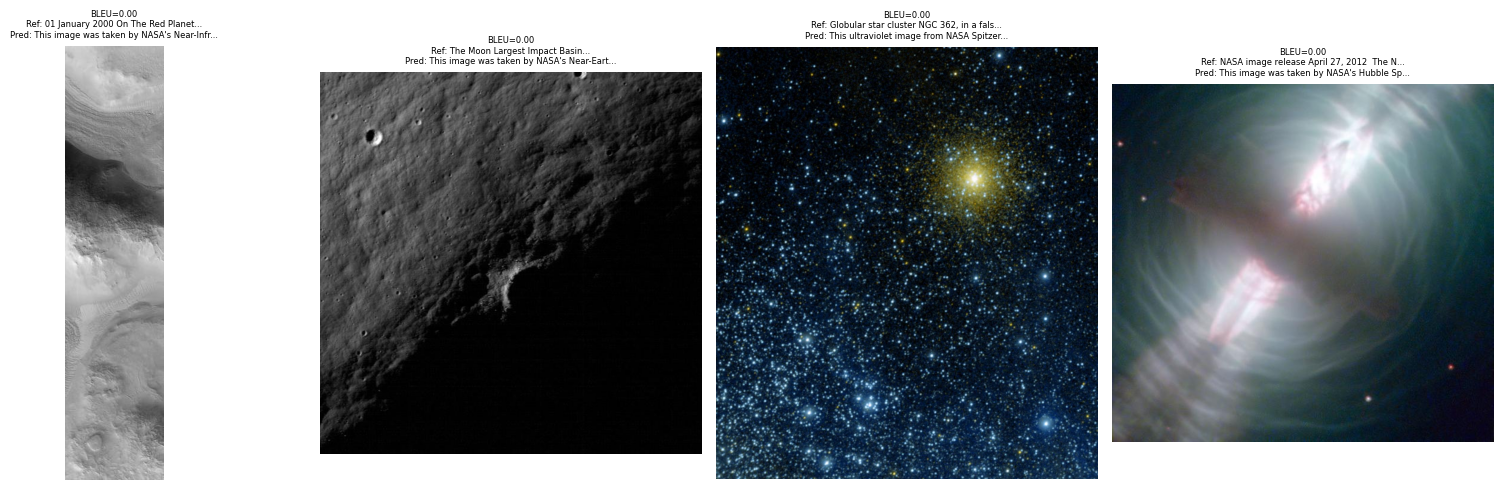

In [15]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

per_sample_bleu = [
    sentence_bleu(
        [refs[i][0].split()],
        preds_ft[i].split(),
        smoothing_function=SmoothingFunction().method1
    )
    for i in range(len(preds_ft))
]

worst_indices = sorted(range(len(per_sample_bleu)), key=lambda i: per_sample_bleu[i])[:4]

print("=== 4 Worst Predictions ===\n")
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, idx in zip(axes, worst_indices):
    row = val_df.iloc[idx]
    img = Image.open(
        os.path.join(IMAGES_DIR, os.path.basename(row['image_file_path']))
    ).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f"BLEU={per_sample_bleu[idx]:.2f}\n"
        f"Ref: {refs[idx][0][:40]}...\n"
        f"Pred: {preds_ft[idx][:40]}...",
        fontsize=6
    )
    ax.axis('off')
plt.tight_layout()
plt.savefig("error_analysis.png")
plt.show()

###**Reflection**
**Error Analysis**


### Error Analysis

**All 4 worst predictions score BLEU=0.00**not because they are completely
wrong,
* but because BLEU requires exact n-gram matches and our reference
captions contain highly specific catalog numbers, dates, and object names
(e.g. "NGC 362", "01 January 2000") that the model cannot reproduce exactly
from visual input alone.

* Qualitatively the predictions show clear improvement — the model correctly
identifies these as NASA space images and uses domain-appropriate vocabulary
("Hubble Space Telescope", "NASA Spitzer") even when it fails on specifics.

#Main failure modes:
- **Hallucination**: model copies training caption patterns but fills in
  wrong specific details (wrong dates, wrong catalog numbers)
- **Over-generalization**: crowded star cluster images default to generic
  "ultraviolet image" descriptions
- **Dataset size**: 168 training images is too few to learn rare object
  types like specific crater names or impact basins

##**Similarity Search — Bonus Feature**
We reuse the ViT encoder (already part of our model) as an image embedding
engine.
* The CLS token output is a 768-dimensional summary of the image.
* Cosine similarity between two CLS vectors measures visual similarity.
* This gives us a Search mode at zero extra cost — no new model needed.

In [16]:
import torch.nn.functional as F

def get_embedding(image: Image.Image) -> torch.Tensor:
    pixel_values = feature_extractor(
        images=image.convert("RGB"), return_tensors="pt"
    ).pixel_values.to(device)
    with torch.no_grad():
        embedding = model_finetuned.encoder(pixel_values).last_hidden_state[:, 0, :]
    return embedding.cpu()

# Build index once
print("Building embedding index...")
embeddings, index_rows = [], []
for i, row in df.iterrows():
    try:
        img = Image.open(
            os.path.join(IMAGES_DIR, os.path.basename(row['image_file_path']))
        ).convert("RGB")
        embeddings.append(get_embedding(img))
        index_rows.append(row)
    except:
        pass

all_embeddings = torch.cat(embeddings, dim=0)
index_df = pd.DataFrame(index_rows).reset_index(drop=True)
print(f"Index built: {len(index_df)} images ✓")

def search_similar(query_image: Image.Image, top_k=3):
    query_emb = get_embedding(query_image)
    sims = F.cosine_similarity(query_emb, all_embeddings)
    top_idx = sims.topk(top_k).indices
    fig, axes = plt.subplots(1, top_k, figsize=(12, 4))
    for ax, idx in zip(axes, top_idx):
        row = index_df.iloc[idx.item()]
        img = Image.open(
            os.path.join(IMAGES_DIR, os.path.basename(row['image_file_path']))
        ).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"sim={sims[idx]:.2f}\n[{row['category']}]\n{row['text'][:50]}", fontsize=7)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Building embedding index...
Index built: 210 images ✓


##  **Interactive Demo**
A Gradio interface combining both modes:
- **Generate**: upload any space image → get an AI-generated caption
- **Search**: upload any space image → find the 3 most visually similar images

In [1]:
import gradio as gr

def run_caption(image):
    pil = Image.fromarray(image)
    global model
    original = model
    model = model_finetuned
    caption = generate_caption(pil)
    model = original
    return caption

def run_search(image):
    pil = Image.fromarray(image)
    query_emb = get_embedding(pil)
    sims = F.cosine_similarity(query_emb, all_embeddings)
    top_idx = sims.topk(3).indices
    results = []
    for idx in top_idx:
        row = index_df.iloc[idx.item()]
        img = Image.open(
            os.path.join(IMAGES_DIR, os.path.basename(row['image_file_path']))
        ).convert("RGB")
        results.append((img, f"[{row['category']}] sim={sims[idx]:.2f}"))
    return results

with gr.Blocks(title=" Space Caption Generator") as demo:
    gr.Markdown("#  Space Caption Generator")
    gr.Markdown("Upload a space image to generate a caption or find similar images.")
    input_image = gr.Image(label="Upload space image")
    with gr.Tab("Generate Caption"):
        caption_btn = gr.Button("Generate")
        caption_out = gr.Textbox(label="Generated Caption")
        caption_btn.click(run_caption, inputs=input_image, outputs=caption_out)
    with gr.Tab("Search Similar"):
        search_btn  = gr.Button("Search")
        gallery_out = gr.Gallery(label="Similar images", columns=3)
        search_btn.click(run_search, inputs=input_image, outputs=gallery_out)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3a5aacf289a01a076b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
